In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

print(df.shape)           # (284807, 31)
print(df.head())
print(df['Class'].value_counts())  # 0 = legit, 1 = fraud

# Check class imbalance
fraud_pct = df['Class'].mean() * 100
print(f"Fraud percentage: {fraud_pct:.2f}%")  # ~0.17%

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

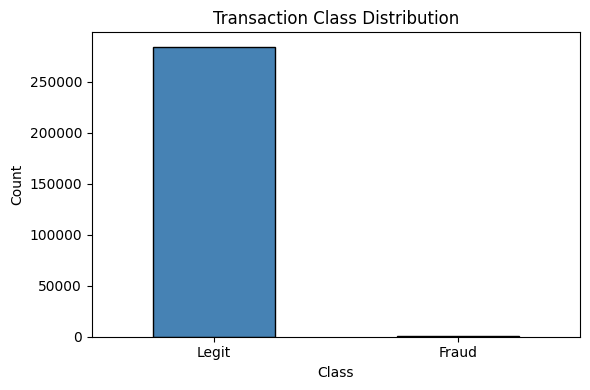

In [3]:
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue','red'],
                                 edgecolor='black')
plt.title("Transaction Class Distribution")
plt.xticks([0,1], ['Legit', 'Fraud'], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
# Scale Amount and Time (V1-V28 are already PCA scaled)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (227845, 30), Test: (56962, 30)


In [5]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# Results
for name, model in [("Logistic Regression", lr), ("Random Forest", rf)]:
    y_pred = model.predict(X_test)
    auc    = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"\n{'='*45}\n{name}  |  ROC-AUC: {auc:.4f}\n{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Legit','Fraud']))


Logistic Regression  |  ROC-AUC: 0.9698
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest  |  ROC-AUC: 0.9731
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



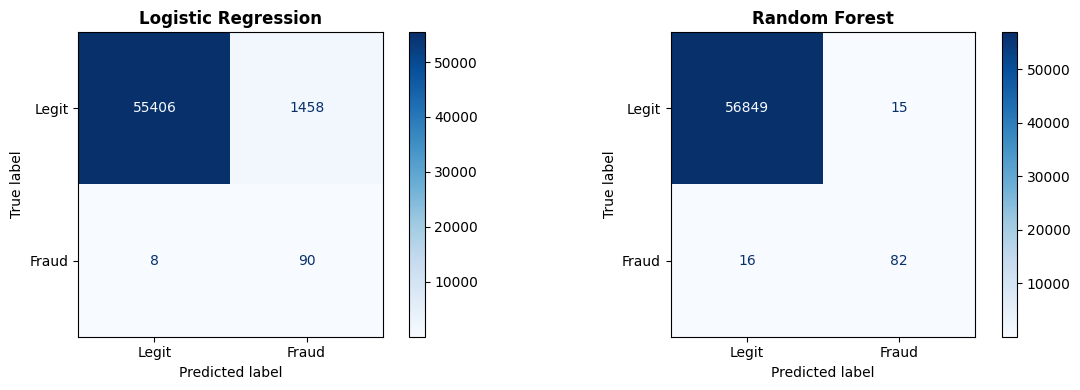

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in zip(axes,
                            [lr, rf],
                            ["Logistic Regression", "Random Forest"]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Legit','Fraud'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.show()

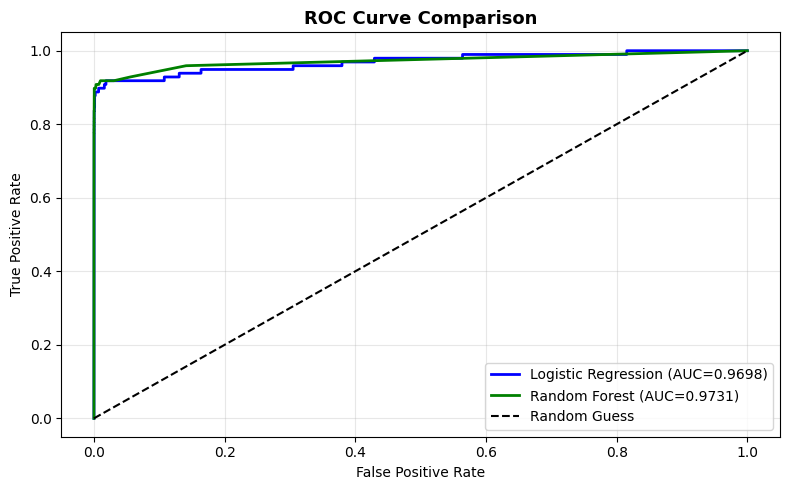

In [8]:
plt.figure(figsize=(8,5))

for model, name, color in [(lr, "Logistic Regression", "blue"),
                            (rf, "Random Forest",       "green")]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', label='Random Guess')
plt.title("ROC Curve Comparison", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

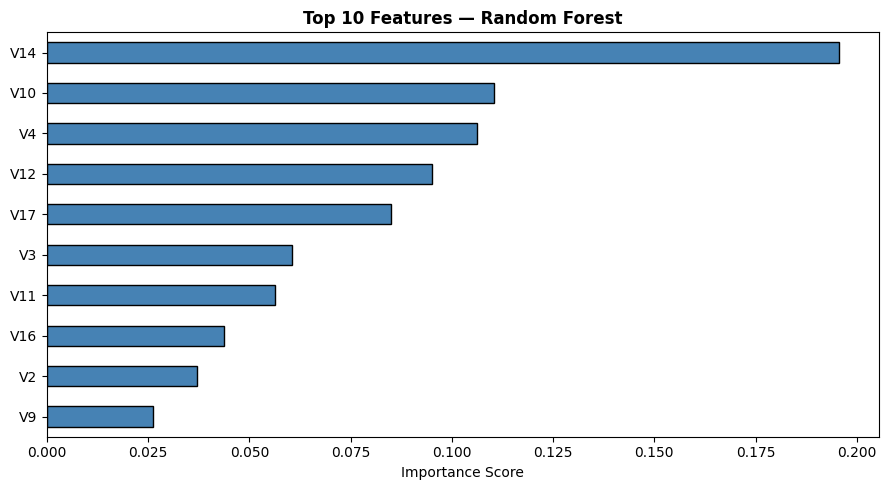

In [9]:
importances = pd.Series(rf.feature_importances_,
                         index=X.columns).sort_values(ascending=False).head(10)

importances.sort_values().plot(kind='barh', figsize=(9,5),
                                color='steelblue', edgecolor='black')
plt.title("Top 10 Features — Random Forest", fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()